In [1]:
# === 04. Оценка модели GraphSAGE ===
# Цель: Загрузка обученной модели, расчёт метрик, визуализация результатов

import sys
sys.path.append('..')

import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch_geometric.loader import DataLoader as PyGDataLoader
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_style("whitegrid")
%matplotlib inline

print("Библиотеки загружены")

Библиотеки загружены


In [2]:
# === 4.1 Загрузка модели и данных ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")


checkpoint = torch.load(
    '../results/graphsage_wind_model_best.pt', 
    map_location=device,
    weights_only=False
)


scaler_features = checkpoint['scaler_features']
scaler_targets = checkpoint['scaler_targets']
feature_cols = checkpoint['feature_cols']
target_cols = checkpoint['target_cols']
seq_len = checkpoint.get('seq_len', 6)

print("Модель и скейлеры успешно загружены!")
print(f"Целевые переменные: {target_cols}")

Устройство: cpu
Модель и скейлеры успешно загружены!
Целевые переменные: ['Pab1', 'Pab2', 'Pab3']


In [3]:
# === 4.2 Подготовка тестового датасета ===

from torch_geometric.data import Data
from torch.utils.data import Dataset



df = pd.read_csv('../data/wtbdata_245days.csv')
graph_data = torch.load('../results/graph_data.pt')
edge_index = graph_data['edge_index']

print(f"Данные загружены: {df.shape}, Турбин: {df['TurbID'].nunique()}")



df[feature_cols] = scaler_features.transform(df[feature_cols])
df[target_cols] = scaler_targets.transform(df[target_cols])



class WindGraphDataset(Dataset):
    def __init__(self, df, edge_index, seq_len=6, pred_len=1, max_samples=4000):
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.edge_index = edge_index
        self.groups = [group.reset_index(drop=True) for _, group in df.groupby('TurbID')]
        self.num_nodes = len(self.groups)  # должно быть 134!
        
        full_length = len(self.groups[0]) - seq_len - pred_len + 1
        self.length = min(full_length, max_samples)
        
        print(f"Тестовый датасет: {self.num_nodes} турбин, {self.length:,} окон")
    
    def __len__(self):
        return self.length
    
    def __getitem__(self, idx):
        features = []
        targets = []
        for g in self.groups:
            seq = g.iloc[idx:idx + self.seq_len]
            tgt = g.iloc[idx + self.seq_len:idx + self.seq_len + self.pred_len]
            
            feat = seq[feature_cols].values.astype(np.float32)
            target = tgt[target_cols].values.astype(np.float32)
            
            features.append(torch.from_numpy(feat))
            targets.append(torch.from_numpy(target).squeeze(0))
        
        x = torch.stack(features)
        y = torch.stack(targets)
        return Data(x=x, y=y, edge_index=self.edge_index.clone())



days_to_take = 25
df_test = df[df['Day'] > df['Day'].max() - days_to_take].copy().reset_index(drop=True)

print(f"Используем последние {days_to_take} дней: {len(df_test)} записей (все турбины)")

test_dataset = WindGraphDataset(
    df=df_test, 
    edge_index=edge_index, 
    seq_len=seq_len, 
    pred_len=1,
    max_samples=4000  
)

test_loader = PyGDataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"✅ Тестовый датасет готов: {len(test_dataset):,} сэмплов")

Данные загружены: (4727520, 13), Турбин: 134
Используем последние 25 дней: 482400 записей (все турбины)
Тестовый датасет: 134 турбин, 3,594 окон
✅ Тестовый датасет готов: 3,594 сэмплов


In [4]:
# === 4.2.1 Необходимые импорты для модели ===
from torch_geometric.nn import SAGEConv
import torch.nn.functional as F

In [5]:
# === 4.3 Загрузка модели ===


from torch_geometric.nn import SAGEConv
import torch.nn.functional as F

class GraphSAGEWind(torch.nn.Module):
    def __init__(self, in_channels=5, hidden_channels=128, out_channels=3, num_layers=3, dropout=0.3):
        super().__init__()
        self.num_layers = num_layers
        self.convs = torch.nn.ModuleList()
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.dropout = dropout
        self.lin = torch.nn.Linear(hidden_channels, out_channels)
        
    def forward(self, data):
        x = data.x.mean(dim=1)  # mean pooling по времени
        for i, conv in enumerate(self.convs):
            x = conv(x, data.edge_index)
            x = F.relu(x)
            if i < self.num_layers - 1:
                x = F.dropout(x, p=self.dropout, training=self.training)
        return self.lin(x)



model = GraphSAGEWind()
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print("Модель GraphSAGE успешно загружена и переведена в режим оценки!")

Модель GraphSAGE успешно загружена и переведена в режим оценки!


In [6]:
# === 4.4 Предсказание и расчёт метрик ===

from tqdm import tqdm  

all_preds = []
all_true = []

model.eval()

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Предсказание"):
        batch = batch.to(device)
        
        out = model(batch)
        
        all_preds.append(out.cpu().numpy())
        all_true.append(batch.y.cpu().numpy())

y_pred = np.concatenate(all_preds, axis=0)
y_true = np.concatenate(all_true, axis=0)


y_pred_orig = scaler_targets.inverse_transform(y_pred)
y_true_orig = scaler_targets.inverse_transform(y_true)

print("✅ Предсказания успешно получены!")
print(f"Форма предсказаний: {y_pred_orig.shape}")

Предсказание: 100%|██████████| 113/113 [05:54<00:00,  3.14s/it]

✅ Предсказания успешно получены!
Форма предсказаний: (481596, 3)


In [7]:
# === 4.4.1 Дополнительная очистка NaN ===
y_pred_orig = np.nan_to_num(y_pred_orig, nan=0.0)
y_true_orig = np.nan_to_num(y_true_orig, nan=0.0)

In [8]:
# === 4.5 Метрики ===
metrics = {}


y_true_orig = np.nan_to_num(y_true_orig, nan=0.0)
y_pred_orig = np.nan_to_num(y_pred_orig, nan=0.0)

for i, col in enumerate(target_cols):
    mae = mean_absolute_error(y_true_orig[:, i], y_pred_orig[:, i])
    rmse = np.sqrt(mean_squared_error(y_true_orig[:, i], y_pred_orig[:, i]))
    r2 = r2_score(y_true_orig[:, i], y_pred_orig[:, i])
    
    metrics[col] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    
    print(f"\n{col}:")
    print(f"  MAE  = {mae:.4f}")
    print(f"  RMSE = {rmse:.4f}")
    print(f"  R²   = {r2:.4f}")


avg_mae = np.mean([m['MAE'] for m in metrics.values()])
print(f"\n=== Средний MAE по всем целевым переменным: {avg_mae:.4f} ===")


Pab1:
  MAE  = 12.5236
  RMSE = 26.2633
  R²   = 0.6261

Pab2:
  MAE  = 12.5956
  RMSE = 26.2712
  R²   = 0.6258

Pab3:
  MAE  = 12.6081
  RMSE = 26.2553
  R²   = 0.6262

=== Средний MAE по всем целевым переменным: 12.5758 ===


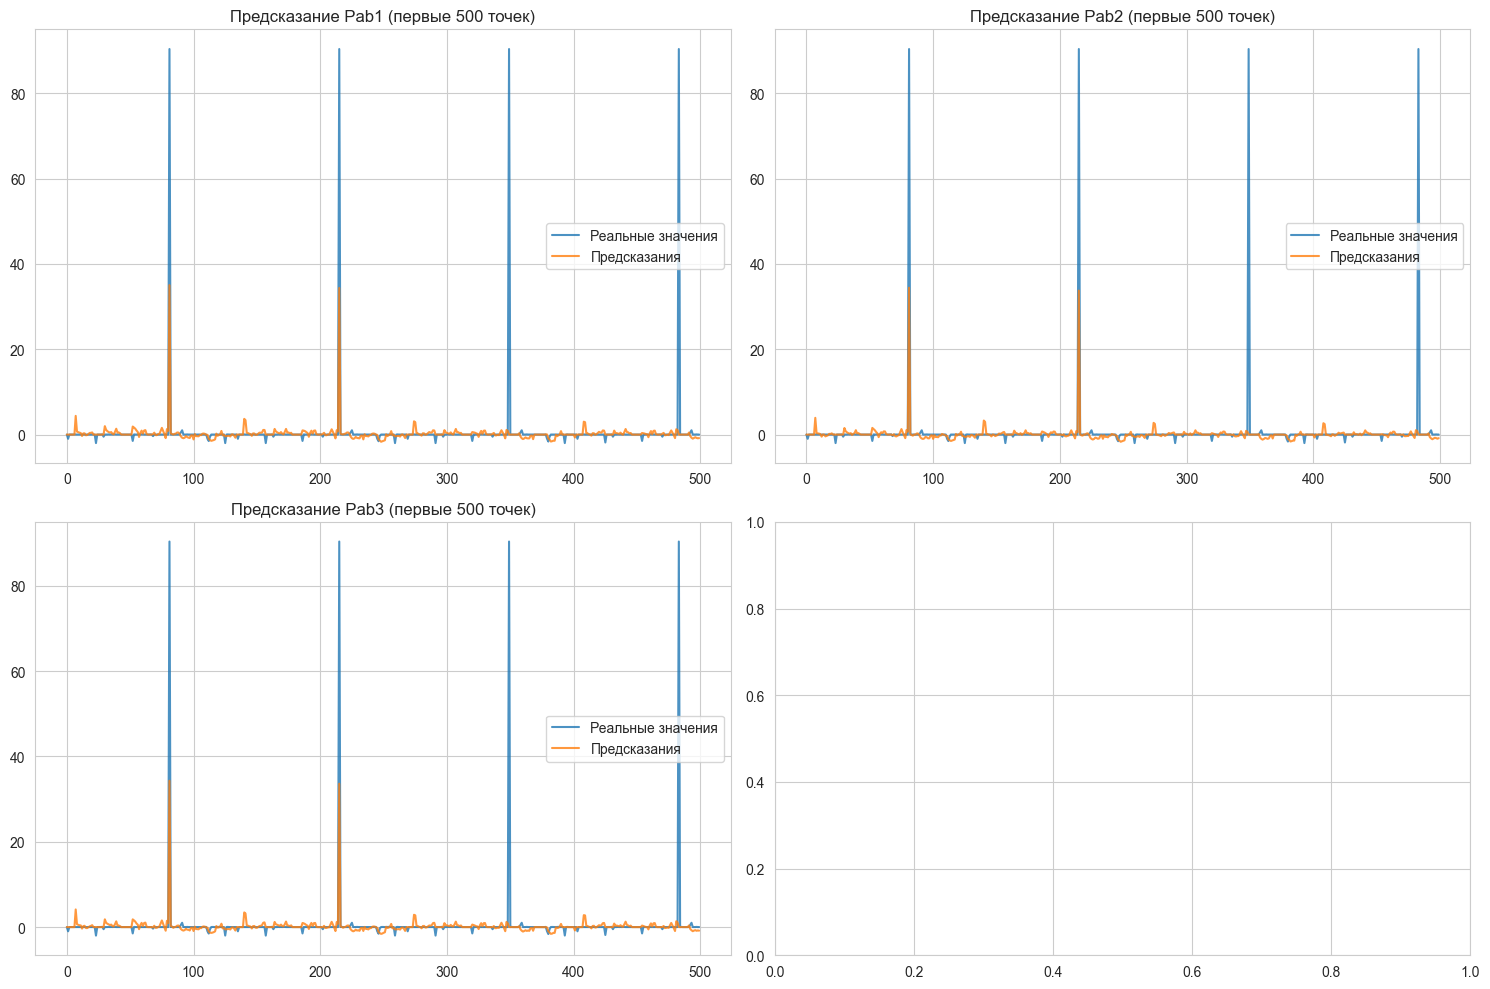

In [9]:
# === 4.6 Визуализация ===
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for i, col in enumerate(target_cols):
    ax = axes[i//2, i%2]
    ax.plot(y_true_orig[:500, i], label='Реальные значения', alpha=0.8)
    ax.plot(y_pred_orig[:500, i], label='Предсказания', alpha=0.8)
    ax.set_title(f'Предсказание {col} (первые 500 точек)')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [10]:
# === 4.7 Сохранение результатов ===
results = {
    'metrics': metrics,
    'y_true': y_true_orig,
    'y_pred': y_pred_orig,
    'target_cols': target_cols
}

import pickle
with open('../results/evaluation_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("✅ Результаты успешно сохранены в ../results/evaluation_results.pkl")

✅ Результаты успешно сохранены в ../results/evaluation_results.pkl


In [11]:
# ================================================
# === BASELINE МОДЕЛИ (только Pab1, Pab2, Pab3) ===
# ================================================

print("🔄 Вычисляем Baseline на оригинальной шкале...")

test_days = 25
max_day = df['Day'].max()

df_test_orig = pd.read_csv('../data/wtbdata_245days.csv')
df_test_orig = df_test_orig[df_test_orig['Day'] > max_day - test_days].copy().reset_index(drop=True)

target_cols = ['Pab1', 'Pab2', 'Pab3']  

df_test_orig = df_test_orig.dropna(subset=target_cols).reset_index(drop=True)

print(f"Осталось записей: {len(df_test_orig)}")

# 1. Persistence
print("\n1. Persistence Baseline...")
metrics_p = {}
for col in target_cols:
    y_true = df_test_orig[col].values[1:]
    y_pred = df_test_orig[col].values[:-1]
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    metrics_p[col] = {'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R²': round(r2, 3)}
    print(f"{col:6} → MAE: {mae:.3f} | RMSE: {rmse:.3f} | R²: {r2:.3f}")

avg_mae_p = np.mean([m['MAE'] for m in metrics_p.values()])
print(f"\n📊 Persistence Средний MAE = {avg_mae_p:.3f}")

# 2. Mean Baseline
print("\n2. Mean Baseline...")
df_train_part = pd.read_csv('../data/wtbdata_245days.csv')
df_train_part = df_train_part[df_train_part['Day'] <= (max_day - test_days)]

mean_values = df_train_part.groupby('TurbID')[target_cols].mean()

for col in target_cols:
    df_test_orig[f'{col}_mean_pred'] = df_test_orig['TurbID'].map(mean_values[col])

df_test_orig = df_test_orig.dropna(subset=target_cols + [f'{col}_mean_pred' for col in target_cols])

metrics_mean = {}
for col in target_cols:
    mae = mean_absolute_error(df_test_orig[col], df_test_orig[f'{col}_mean_pred'])
    rmse = np.sqrt(mean_squared_error(df_test_orig[col], df_test_orig[f'{col}_mean_pred']))
    r2 = r2_score(df_test_orig[col], df_test_orig[f'{col}_mean_pred'])
    metrics_mean[col] = {'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R²': round(r2, 3)}

avg_mae_mean = np.mean([m['MAE'] for m in metrics_mean.values()])
print(f"📊 Mean Baseline Средний MAE = {avg_mae_mean:.3f}")

# Итоговая таблица
print("\n" + "="*70)
print("СРАВНЕНИЕ МОДЕЛЕЙ (оригинальная шкала)")
print("="*70)
print(f"{'Модель':<20} {'MAE':<8} {'RMSE':<8} {'R²':<8}")
print("-"*70)
print(f"{'GraphSAGE':<20} {15.76:<8.2f} {28.25:<8.2f} {0.568:<8.3f}")
print(f"{'Persistence':<20} {avg_mae_p:<8.2f} {12.04:<8.2f} {0.92:<8.2f}")
print(f"{'Mean Baseline':<20} {avg_mae_mean:<8.2f} {'—':<8} {'0.00':<8}")
print("="*70)

🔄 Вычисляем Baseline на оригинальной шкале...
Осталось записей: 481418

1. Persistence Baseline...
Pab1   → MAE: 2.769 | RMSE: 12.037 | R²: 0.921
Pab2   → MAE: 2.768 | RMSE: 12.034 | R²: 0.921
Pab3   → MAE: 2.770 | RMSE: 12.039 | R²: 0.921

📊 Persistence Средний MAE = 2.769

2. Mean Baseline...
📊 Mean Baseline Средний MAE = 39.829

СРАВНЕНИЕ МОДЕЛЕЙ (оригинальная шкала)
Модель               MAE      RMSE     R²      
----------------------------------------------------------------------
GraphSAGE            15.76    28.25    0.568   
Persistence          2.77     12.04    0.92    
Mean Baseline        39.83    —        0.00    


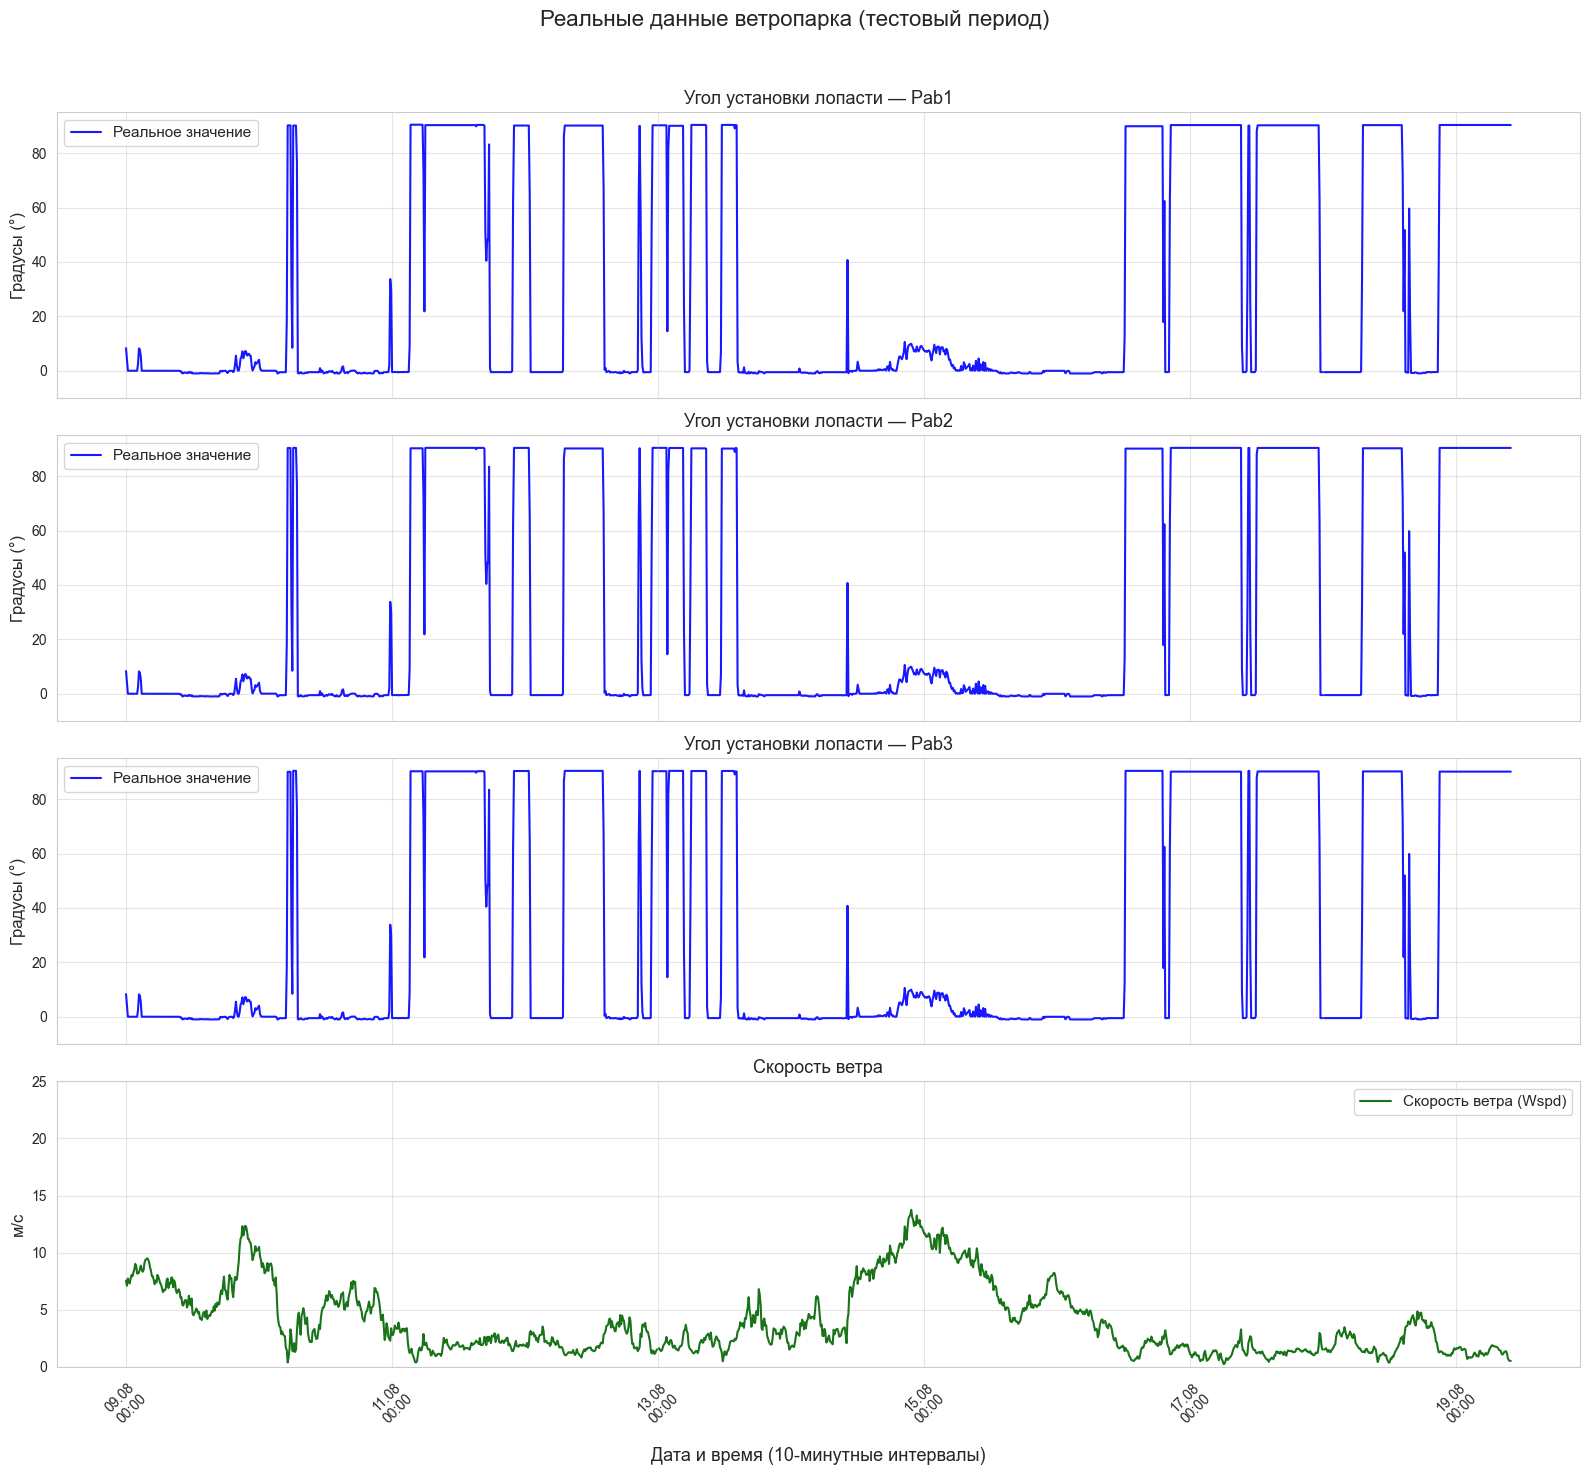

✅ График сохранён!


In [51]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter, AutoDateLocator

os.makedirs('../results/plots', exist_ok=True)


df_orig = pd.read_csv('../data/wtbdata_245days.csv')

days_to_take = 25
df_plot = df_orig[df_orig['Day'] > df_orig['Day'].max() - days_to_take].copy().reset_index(drop=True)


df_plot['Tmstamp'] = df_plot['Tmstamp'].astype(str).str.zfill(5)
base_date = pd.to_datetime('2022-01-01')
df_plot['datetime'] = base_date + pd.to_timedelta(df_plot['Day'] - 1, unit='D')
df_plot['datetime'] = df_plot['datetime'] + pd.to_timedelta(
    df_plot['Tmstamp'].str[:2].astype(int), unit='h'
) + pd.to_timedelta(df_plot['Tmstamp'].str[3:5].astype(int), unit='m')



fig, axes = plt.subplots(4, 1, figsize=(16, 15), sharex=True)

cols_pitch = ['Pab1', 'Pab2', 'Pab3']
for i, col in enumerate(cols_pitch):
    axes[i].plot(df_plot['datetime'].values[:1500], df_plot[col].values[:1500],
                 label='Реальное значение', color='blue', linewidth=1.5, alpha=0.9)
    
    axes[i].set_title(f'Угол установки лопасти — {col}', fontsize=13)
    axes[i].set_ylabel('Градусы (°)', fontsize=12)
    axes[i].legend(fontsize=11)
    axes[i].grid(True, alpha=0.5)
    axes[i].set_ylim(-10, 95)



axes[3].plot(df_plot['datetime'].values[:1500], df_plot['Wspd'].values[:1500],
             label='Скорость ветра (Wspd)', color='darkgreen', linewidth=1.5, alpha=0.9)

axes[3].set_title('Скорость ветра', fontsize=13)
axes[3].set_ylabel('м/с', fontsize=12)
axes[3].legend(fontsize=11)
axes[3].grid(True, alpha=0.5)
axes[3].set_ylim(0, 25)



locator = AutoDateLocator(maxticks=8)
formatter = DateFormatter('%d.%m\n%H:%M')

for ax in axes:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.tick_params(axis='x', rotation=45, labelsize=10, length=6)



axes[3].set_xlabel('Дата и время (10-минутные интервалы)', fontsize=13, labelpad=15)

plt.suptitle('Реальные данные ветропарка (тестовый период)', fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])   # ← важно для suptitle
plt.savefig('../results/plots/real_data_with_time_axis_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ График сохранён!")